<a href="https://colab.research.google.com/github/Alokathilakarathna/ME422_B3/blob/main/RIgid%20Body%20Control/e20452.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p align="center" style="font-family: 'Times New Roman';"><b>RIGID BODYC ONTROL SYSTEMS LABORATORY</b></p>
<p align="center" style="font-family: 'Times New Roman'; color: #555;">ME 422: Mechanical Systems Lab</p>
<hr/>
<p align="center"> W.S.P.Y.J.C.YAPA   |  E/20/452</p>
<hr/>

In [2]:
!pip install control

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 12.9 MB/s eta 0:00:00


In [1]:
import numpy as np
import control as ct
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# **Activity 1 - Twin rotor system dynamic model**

## Definition of Coordinate Frames and Rotational Matrices

<p align="center">
  <img src="https://raw.githubusercontent.com/Alokathilakarathna/ME422_B3/main/images/TR_frames.png" />
  <br>
  <i>Figure 01: Setup and Coordinate Frame Definition</i>
</p>

Considering the physical structure of the setup, let's define three coordinate frames,
1. Inertial Frame $(e)$: The fixed global frame.
2. Intermediate Frame $(c)$: Fixed to the vertical pillar. It rotates relative to e around the vertical axis $(e_3  \equiv c_3)$ by the yaw angle $θ$.
3. Body Frame $(b)$: Fixed to the pitching arm. It rotates relative to c around the horizontal axis $(c_1  \equiv b$1)$ by the pitch angle $ϕ$

as shown in figure 01.

The relation between those frames are,

$$ c = e R_3(θ)$$
$$ b = c R_1(ϕ)$$

Therefore,

$$ b = e R_3(θ) R_1(ϕ)$$
$$ b = e R \tag{01}$$

Where, $R$ is the Rotational matrix.

Since,
$$
R_1(\phi)=\begin{bmatrix}
1&0&0\\
0&\cos{\phi}&-\sin{\phi}\\
0&\sin{\phi}&\cos{\phi}
\end{bmatrix}
$$

and

$$
R_3(\theta)=\begin{bmatrix}
\cos{\theta}&-\sin{\theta}&0\\
\sin{\theta}&\cos{\theta}&0\\
0&0&1
\end{bmatrix}
$$

Final Rotational Matrix,
$$R = R_3 R_1 = \begin{bmatrix}
\cos{\theta}&-\cos{\phi}\sin{\theta}&\sin{\phi}\sin{\theta}\\
\sin{\theta}&\cos{\phi}\cos{\theta}&-\sin{\phi}\cos{\theta}\\
0&\sin{\phi}&\cos{\phi}\end{bmatrix} \tag{02}$$



## Derivation of Kinematic Equation




From (02),

$$ R = R_3 R_1 $$
By taking time derivative,
$$ \dot{R} = \dot{R_3} R_1 +  R_3 \dot{R_1} \tag{03}$$

For any rotation matrix,
$$ \dot{R} = \hat{ω} R = R \hat{Ω}$$
Where $ω$ is spatial angular velocity and $Ω$ is body angular velocity.

Therefore,
$$ \dot{R_1} = \hat{ω_1} R_1 $$
$$ \dot{R_3} = \hat{ω_2} R_3 $$

By substituing that back to 03,

$$\dot{R} = \hat{\omega}_3 (R_3 R_1) + R_3 \hat{\omega}_1(R_3^T R_3)R_1 $$
$$\dot{R} = \hat{\omega}_3 R + (R_3 \hat{\omega}_1 R_3^T)R$$

$$\dot{R} = (\hat{\omega}_3  + (R_3 \hat{\omega}_1 R_3^T))R$$

$$\dot{R} = \hat{ω} R  \tag{04}$$

Where,
$$\hat{ω} = \hat{\omega}_3  + (R_3 \hat{\omega}_1 R_3^T)$$

By simplifying this,

$$ \hat{\omega} = \begin{bmatrix}
0&-\dot{\theta}&\dot{\phi}\sin{\theta}\\
\dot{\theta}&0&-\dot{\phi}\cos{\theta}\\
-\dot{\phi}\sin{\theta}&\dot{\phi}\cos{\theta}&0
\end{bmatrix}\tag{05}$$


Therefore we can rewrite $Ω$ and $ω$ using $θ$ and $ϕ$ as follow,

$\omega = \begin{bmatrix}
\dot{\phi} \cos{\theta} \\
\dot{\phi} \sin{\theta} \\
\dot{\theta}
\end{bmatrix}$

$
\Omega = R^T \omega = \begin{bmatrix}
\dot{\phi} \\
\dot{\theta} \sin{\phi} \\
\dot{\theta} \cos{\phi}
\end{bmatrix}
$

## Derivation of Torque Equation

In a body frame the angular momentum ($p$),
$$p = 𝕀Ω$$

Then the spatial angular momentum ($π$),

$$π = R p = R 𝕀 Ω$$
$$π = R 𝕀 R_T ω$$
$$π = 𝕀^R ω$$

In here $𝕀^R$ is defined as spatial inertia tensor.

Then by inverting inertial matrix we get the given equation,

$$ω = (𝕀^R)^{-1} π$$

By fundamental law of rotational dynamics,
$$ \dot{π} = \sum τ_{ext}$$

In this setup the external moment has been split into two distinct parts,

1. The manipulatable control moment - $\tau^u$
1. The unmanipulatable constraint moment - $\tau^e$ (Which occurs due to the pivot preventing rotation about the $b_2$ axis)

Therefore,
$$ \dot{π} = \tau^u + \tau^e \tag{06}$$


## Defining $\tau^u$ and $\tau^e$

*In here the derivation are done for general setup (for any rotor orientation)*

Let's define following terms for trust generatedby the two rotors,

- $u_1$ : The raw control input (thrust force) generated by the first rotor.

- $u_2$: The raw control input (thrust force) generated by the second rotor.

- $α$: The physical tilt angle of the first rotor. (It defines the angle between Rotor 1's thrust direction and the vertical pitch axis $b_1$)

- $β$: The physical tilt angle of the second rotor. (It defines the angle between Rotor 2's thrust direction and the vertical pitch axis $b_1$)


Considering this terms,

$$
T^u = \begin{bmatrix}
u_1\cos{\alpha}-u_2\cos{\beta}\\
0\\
u_1\sin{\alpha}-u_2\sin{\beta}
\end{bmatrix}
$$

\begin{align*}
\tau_u &=RT^u=R\begin{bmatrix}
u_1\cos{\alpha}-u_2\cos{\beta}\\
0\\
u_1\sin{\alpha}-u_2\sin{\beta}
\end{bmatrix}
\end{align*}

This can rewrite as,
$$
\tau_u =R\begin{bmatrix}
1 & 0\\
0 & 0\\
0 & 1
\end{bmatrix}
\begin{bmatrix}
\cos{\alpha} & -\cos{\beta}\\
\sin{\alpha} & -\sin{\beta}
\end{bmatrix}
\begin{bmatrix}
u_1\\ u_2
\end{bmatrix} \tag{07}$$

The constriant moment acting on the system prevents a rotation about $b_2$ axis therere,

From Euler's rigid body equations,

$$
T^u + T^e = \Omega \times \mathbb{I}\Omega+\mathbb{I}\dot{\Omega}
$$

To isolate $T_2$ multiply it by $e_2$ and we can take following equation,

$$
T_2 = e_2^T (\Omega \times \mathbb{I}\Omega+\mathbb{I}\dot{\Omega})
$$


Therefore,

$$
T^e=\begin{bmatrix}0\\T_2\\0
\end{bmatrix}
$$

$$
\tau^e=R\begin{bmatrix}0\\T_2\\0
\end{bmatrix}
$$

# **Activity 2 - Simulate and animate the motion of the system for various different realistic inputs**

The dynamics are governed by Euler's rigid body equations in the body frame b,
$$ T_u+T_e = I\dot{Ω}+Ω×(𝕀Ω)$$

The angular velocity in body frame,

$$\Omega = \begin{bmatrix} \dot{\phi} \\ \dot{\theta} \sin \phi \\ \dot{\theta} \cos \phi \end{bmatrix}$$

The angular acceleration in body frame

$$\dot{\Omega} = \begin{bmatrix} \ddot{\phi} \\ \ddot{\theta} \sin \phi + \dot{\theta}\dot{\phi} \cos \phi \\ \ddot{\theta} \cos \phi - \dot{\theta}\dot{\phi} \sin \phi \end{bmatrix}$$

Take $\mathbb{I} = \text{diag}(I_1, I_2, I_3)$.

gyroscopic effect term $\Omega \times (\mathbb{I}\Omega)$,

$$\Omega \times (\mathbb{I}\Omega) = \begin{bmatrix} \dot{\phi} \\ \dot{\theta} \sin \phi \\ \dot{\theta} \cos \phi \end{bmatrix} \times \begin{bmatrix} I_1 \dot{\phi} \\ I_2 \dot{\theta} \sin \phi \\ I_3 \dot{\theta} \cos \phi \end{bmatrix}$$

$$\Omega \times (\mathbb{I}\Omega) = \begin{bmatrix} (I_3 - I_2) \dot{\theta}^2 \sin \phi \cos \phi \\ (I_1 - I_3) \dot{\theta}\dot{\phi} \cos \phi \\ (I_2 - I_1) \dot{\theta}\dot{\phi} \sin \phi \end{bmatrix}$$

Trust Torque,
$$
T^u = \begin{bmatrix}
u_1\cos{\alpha}-u_2\cos{\beta}\\
0\\
u_1\sin{\alpha}-u_2\sin{\beta}
\end{bmatrix}
$$

External Reaction Torque,
$$
T^e=\begin{bmatrix}0\\T_2\\0
\end{bmatrix}
$$

Substituting the therms,

$$
\begin{bmatrix}
u_1 \cos \alpha - u_2 \cos \beta \\
0 \\
u_1 \sin \alpha - u_2 \sin \beta
\end{bmatrix} +
\begin{bmatrix}
0 \\
T_2 \\
0
\end{bmatrix} =
\begin{bmatrix}
I_1 \ddot{\phi} \\
I_2 (\ddot{\theta} \sin \phi + \dot{\theta}\dot{\phi} \cos \phi) \\
I_3 (\ddot{\theta} \cos \phi - \dot{\theta}\dot{\phi} \sin \phi)
\end{bmatrix} +
\begin{bmatrix}
(I_3 - I_2) \dot{\theta}^2 \sin \phi \cos \phi \\
(I_1 - I_3) \dot{\theta}\dot{\phi} \cos \phi \\
(I_2 - I_1) \dot{\theta}\dot{\phi} \sin \phi
\end{bmatrix}
$$

Therefore,

$$
\begin{aligned}
u_1 \cos \alpha - u_2 \cos \beta &= I_1 \ddot{\phi} + (I_3 - I_2) \dot{\theta}^2 \sin \phi \cos \phi \\
T_2 &= I_2 (\ddot{\theta} \sin \phi + \dot{\theta}\dot{\phi} \cos \phi) + (I_1 - I_3) \dot{\theta}\dot{\phi} \cos \phi \\
u_1 \sin \alpha - u_2 \sin \beta &= I_3 (\ddot{\theta} \cos \phi - \dot{\theta}\dot{\phi} \sin \phi) + (I_2 - I_1) \dot{\theta}\dot{\phi} \sin \phi
\end{aligned}
$$


State vector taken as,
$$x=[θ,ϕ,\dot{θ},\dot{ϕ}]^T$$


$$
\ddot{\phi} = \frac{1}{I_1}\left(( u_1 \cos \alpha - u_2 \cos \beta )- (I_3 - I_2) \dot{\theta}^2 \sin \phi \cos \phi \right )
$$

$$
\ddot{\theta} = \frac{1}{\cos \phi}\left( \dot{\theta}\dot{\phi} \sin \phi + \frac{1}{I_3}(u_1 \sin \alpha - u_2 \sin \beta - (I_2 - I_1) \dot{\theta}\dot{\phi} \sin \phi)\right )
$$


### **SPECIAL NOTE**
---

The system dynamics of the twin rotor is actually non-linear due to following terms incuded in the system dynamics equations,
 - $\dot{\theta}^2 \sin \phi \cos \phi$ - centrifugal force and Gyroscopic Effect
 When rotors rotates about one axis, the difference in the moments of inertia $(I_3 -I_2)$ causes an induced torque on the other axes.

 - $\dot{\theta}\dot{\phi} \sin \phi$ - Coriolis Torques
 represents the torque required to change the direction of an angular momentum vector.

 - $\frac{1}{\cos \phi}$ - Singularity
 As the angle $ϕ$ approaches $π/2$, $cosϕ$ approaches zero, causing the term to shoot toward infinity.This represents gimbal lock

 - Other Triganomatric functions
  



## Calcualating Inertia Matrix

Let's define setup in simplified shapes.
- The Arm: A slender solid cylinder with mass $m_a$ radius $r_a$, and a total length of $2L_a$ (The distance from the center pivot to one end is $L_a$).

- The Rotors: Two solid discs (motors + propellers) with mass $m_r$ and radius $r_r$, distance from center pivot to motor is $L_r$.

$I_1$: Pitch Inertia (Around the $b_1$ axis)

$$I_1 = \frac{1}{3}m_a L_a^2 + 2 m_r L_r^2$$

$I_2$: Roll Inertia (Around the $b_2$ axis)

$$I_2 = \frac{1}{2}m_a r_a^2 +  m_r r_r^2$$

$I_3$: Yaw Inertia (Around the $b_3$ axis)

$$I_3 = I_1 = \frac{1}{3}m_a L_a^2 + 2 m_r L_r^2$$


Final matrix,

$$ 𝕀 = diag\{ I_1, I_2, I_3 \}$$

## Test Code : Deprecated

In [2]:
# The Arm (Slender solid cylinder)
m_a = 0.25  # Mass of the arm (kg)
r_a = 0.02  # Radius of the arm cross-section (m)
L_a = 0.30  # Distance from center pivot to one end of the arm (m)
# The Rotors (Motors + Propellers acting as solid discs)
m_r = 0.15  # Mass of one rotor unit (kg)
r_r = 0.06  # Radius of the rotor/propeller disc (m)
L_r = 0.28  # Distance from center pivot to the motor center (m)


I1 = (1/3) * m_a * (L_a**2) + 2 * m_r * (L_r**2)
I2 = (1/2) * m_a * (r_a**2) + m_r * (r_r**2)
I3 = I1
I = np.diag([I1, I2, I3])


In [40]:
alpha = np.radians(0) # Tilt angle rotor 1
beta = np.radians(90)  # Tilt angle rotor 2

In [41]:
def TwinRotorDynamics(t, x, u, params):
    theta, phi, d_theta, d_phi = x
    # theta = (theta + np.pi) % (2 * np.pi) - np.pi
    # phi = (phi + np.pi) % (2 * np.pi) - np.pi

    u1, u2 = u[0], u[1]

    # Avoid the gimble lock singularity
    cos_phi = np.cos(phi) if abs(np.cos(phi)) > 1e-5 else 1e-5

    d2_phi = (1 / I1) * ((u1 * np.cos(alpha) - u2 * np.cos(beta)) - (I3 - I2) * (d_theta**2) * np.sin(phi) * np.cos(phi))
    d2_theta = (1 / cos_phi) * (d_theta * d_phi * np.sin(phi) + (1 / I3) * (u1 * np.sin(alpha) - u2 * np.sin(beta) - (I2 - I1) * d_theta * d_phi * np.sin(phi)))

    return [d_theta, d_phi, d2_theta, d2_phi]

In [42]:
TwinRotorSsytem = ct.NonlinearIOSystem(
    TwinRotorDynamics,
    states=4, name='TwinRotor',
    inputs=('u1', 'u2'), outputs=('theta', 'phi', 'theta_dot', 'phi_dot')
)

T = np.linspace(0, 10, 500)
U = np.zeros((2, len(T)))

# --- Sinusoidal Input Parameters ---
base_thrust = 0.0100  # A small baseline thrust to simulate "hovering"
amplitude = 0.0050    # Gentle oscillation (+/- 0.05 N)
frequency = 0.2      # 0.2 Hz (1 wave every 5 seconds)

U[0, :] = base_thrust + amplitude * np.sin(2 * np.pi * frequency * T)
U[1, :] = base_thrust - amplitude * np.sin(2 * np.pi * frequency * T)
# U[0, :] = 0.1
# U[1, :] = 0.2

T_out, Y_out = ct.input_output_response(TwinRotorSsytem, T, U, X0=[0,0,0,0])

In [43]:
# Wrap the Theta array (Row 0)
Y_out[0, :] = (Y_out[0, :] + np.pi) % (2 * np.pi) - np.pi

# Wrap the Phi array (Row 1)
Y_out[1, :] = (Y_out[1, :] + np.pi) % (2 * np.pi) - np.pi

fig = make_subplots(
    rows=3, cols=1,
    shared_xaxes=True,
    subplot_titles=(
        "Control Inputs (Thrust)",
        "System Angles (Positions)",
        "Angular Velocities (Rates)"
    ),
    vertical_spacing=0.1
)

# --- Inputs (U) ---
fig.add_trace(go.Scatter(x=T, y=U[0], name='u1 (Rotor 1)', line=dict(color='#1f77b4', width=2)), row=1, col=1)
fig.add_trace(go.Scatter(x=T, y=U[1], name='u2 (Rotor 2)', line=dict(color='#00d2d3', width=2, dash='dash')), row=1, col=1)

# --- Angles (Y_out[0] and Y_out[1]) ---
fig.add_trace(go.Scatter(x=T_out, y=Y_out[0], name='Theta (Yaw)', line=dict(color='#2ca02c', width=2)), row=2, col=1)
fig.add_trace(go.Scatter(x=T_out, y=Y_out[1], name='Phi (Pitch)', line=dict(color='#98df8a', width=2)), row=2, col=1)

# --- Velocities (Y_out[2] and Y_out[3]) ---
fig.add_trace(go.Scatter(x=T_out, y=Y_out[2], name='Theta Dot', line=dict(color='#d62728', width=2)), row=3, col=1)
fig.add_trace(go.Scatter(x=T_out, y=Y_out[3], name='Phi Dot', line=dict(color='#ff9896', width=2)), row=3, col=1)

fig.update_layout(
    height=800,
    title_text="Twin Rotor System Step Response",
    hovermode="x unified",
    template="plotly_dark",
    showlegend=True
)

# Update axis labels
fig.update_yaxes(title_text="Force (N)", row=1, col=1)
fig.update_yaxes(title_text="Angle (rad)", row=2, col=1)
fig.update_yaxes(title_text="Velocity (rad/s)", row=3, col=1)
fig.update_xaxes(title_text="Time (seconds)", row=3, col=1)

# 3. Render the plot
fig.show()

In [55]:
# @title


# =============================================================================
# Combined 3D Animation: Arm, Simple Disks, and Thrust Vectors
# =============================================================================

theta_vals = Y_out[0, :]
phi_vals = Y_out[1, :]

# Visual Settings
support_height = 0.20
thrust_scale = 0.15
disk_radius = r_r  # 0.06 from your parameters

def get_rotation_matrix(theta, phi):
    R_z = np.array([[np.cos(theta), -np.sin(theta), 0], [np.sin(theta), np.cos(theta), 0], [0, 0, 1]])
    R_x = np.array([[1, 0, 0], [0, np.cos(phi), -np.sin(phi)], [0, np.sin(phi),  np.cos(phi)]])
    return R_z @ R_x

def get_tilt_matrix(angle):
    return np.array([
        [np.cos(angle),  0, np.sin(angle)],
        [0,              1, 0],
        [-np.sin(angle), 0, np.cos(angle)]
    ])

def get_local_circle(r, n=32):
    t = np.linspace(0, 2*np.pi, n)
    return np.array([r*np.cos(t), r*np.sin(t), np.zeros(n)]).T

local_circle = get_local_circle(disk_radius)
R_tilt1 = get_tilt_matrix(alpha)
R_tilt2 = get_tilt_matrix(-beta)

frames = []
skip = 3

for i in range(0, len(T_out), skip):
    R = get_rotation_matrix(theta_vals[i], phi_vals[i])

    # --- 1. Arm & Pillar ---
    support = np.array([[0, 0, 0], [0, 0, -support_height]])
    beam_g = (R @ np.array([[0, -L_a, 0], [0, L_a, 0]]).T).T

    arm_x = [support[0,0], support[1,0], None, beam_g[0,0], beam_g[1,0]]
    arm_y = [support[0,1], support[1,1], None, beam_g[0,1], beam_g[1,1]]
    arm_z = [support[0,2], support[1,2], None, beam_g[0,2], beam_g[1,2]]

    # --- 2. Perpendicular Disks ---
    # We tilt the disk locally, then move it to the end of the arm, then rotate globally
    d1_local_tilted = (R_tilt1 @ local_circle.T).T
    d1_g = (R @ (d1_local_tilted + [0, -L_r, 0]).T).T

    d2_local_tilted = (R_tilt2 @ local_circle.T).T
    d2_g = (R @ (d2_local_tilted + [0,  L_r, 0]).T).T

    disk_x = list(d1_g[:,0]) + [None] + list(d2_g[:,0])
    disk_y = list(d1_g[:,1]) + [None] + list(d2_g[:,1])
    disk_z = list(d1_g[:,2]) + [None] + list(d2_g[:,2])

    # --- 3. Thrust Vectors ---
    t1_s = np.array([0, -L_r, 0])
    t2_s = np.array([0, L_r, 0])
    # Thrust direction matches the disk's normal vector
    t1_e = t1_s + np.array([thrust_scale * np.sin(alpha), 0, thrust_scale * np.cos(alpha)])
    t2_e = t2_s + np.array([-thrust_scale * np.sin(beta), 0, thrust_scale * np.cos(beta)])

    t1s_g, t1e_g = R @ t1_s, R @ t1_e
    t2s_g, t2e_g = R @ t2_s, R @ t2_e

    thrust_x = [t1s_g[0], t1e_g[0], None, t2s_g[0], t2e_g[0]]
    thrust_y = [t1s_g[1], t1e_g[1], None, t2s_g[1], t2e_g[1]]
    thrust_z = [t1s_g[2], t1e_g[2], None, t2s_g[2], t2e_g[2]]

    frames.append(go.Frame(data=[
        go.Scatter3d(x=arm_x, y=arm_y, z=arm_z),
        go.Scatter3d(x=disk_x, y=disk_y, z=disk_z),
        go.Scatter3d(x=thrust_x, y=thrust_y, z=thrust_z)
    ]))

# --- Final Layout ---
axis_limit = L_a + 0.1
main_color = '#00d2d3' # Cyan matching your previous frame

fig3d = go.Figure(
    data=[
        go.Scatter3d(x=frames[0].data[0].x, y=frames[0].data[0].y, z=frames[0].data[0].z,
                     mode='lines', line=dict(color=main_color, width=6), name="Structure"),
        go.Scatter3d(x=frames[0].data[1].x, y=frames[0].data[1].y, z=frames[0].data[1].z,
                     mode='lines', line=dict(color=main_color, width=3), name="Rotor Disks"),
        go.Scatter3d(x=frames[0].data[2].x, y=frames[0].data[2].y, z=frames[0].data[2].z,
                     mode='lines', line=dict(color='#ff7f0e', width=4), name="Thrust Vector")
    ],
    layout=go.Layout(
        template="plotly_dark",
        scene=dict(
            xaxis=dict(range=[-axis_limit, axis_limit]),
            yaxis=dict(range=[-axis_limit, axis_limit]),
            zaxis=dict(range=[-axis_limit, axis_limit]),
            aspectmode='cube'
        ),
        updatemenus=[dict(type="buttons", x=0.1, y=0.9, buttons=[
            dict(label="Play", method="animate", args=[None, dict(frame=dict(duration=25, redraw=True))]),
            dict(label="Pause", method="animate", args=[[None], dict(frame=dict(duration=0, redraw=False))])
        ])]
    ),
    frames=frames
)

fig3d.show()

In [27]:
# @title
import plotly.graph_objects as go
import numpy as np

# =============================================================================
# 3D Animation Setup with Thrust Vectors
# =============================================================================

theta_vals = Y_out[0, :]
phi_vals = Y_out[1, :]

support_height = 0.20
thrust_scale = 0.15 # Length of the thrust arrows in meters

def get_rotation_matrix(theta, phi):
    R_z = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0,              0,             1]
    ])
    R_x = np.array([
        [1, 0,            0],
        [0, np.cos(phi), -np.sin(phi)],
        [0, np.sin(phi),  np.cos(phi)]
    ])
    return R_z @ R_x

frames = []
skip = 2

for i in range(0, len(T_out), skip):
    th = theta_vals[i]
    ph = phi_vals[i]
    R = get_rotation_matrix(th, ph)

    # --- 1. System Geometry (Local to Global) ---
    support = np.array([[0, 0, 0], [0, 0, -support_height]])
    beam_local = np.array([[0, -L_a, 0], [0, L_a, 0]])
    fan1_local = np.array([[r_r, -L_r, 0], [-r_r, -L_r, 0]])
    fan2_local = np.array([[r_r, L_r, 0], [-r_r, L_r, 0]])

    beam_global = (R @ beam_local.T).T
    fan1_global = (R @ fan1_local.T).T
    fan2_global = (R @ fan2_local.T).T

    # Combine Arm Coordinates (Trace 0)
    arm_x = [support[0,0], support[1,0], None, beam_global[0,0], beam_global[1,0], None, fan1_global[0,0], fan1_global[1,0], None, fan2_global[0,0], fan2_global[1,0]]
    arm_y = [support[0,1], support[1,1], None, beam_global[0,1], beam_global[1,1], None, fan1_global[0,1], fan1_global[1,1], None, fan2_global[0,1], fan2_global[1,1]]
    arm_z = [support[0,2], support[1,2], None, beam_global[0,2], beam_global[1,2], None, fan1_global[0,2], fan1_global[1,2], None, fan2_global[0,2], fan2_global[1,2]]

    # --- 2. Thrust Vectors (Local to Global) ---
    # Based on alpha/beta, thrust has a Z component (cos) and an X component (sin) for yaw
    # Start points are the rotor centers
    t1_start = np.array([0, -L_r, 0])
    t2_start = np.array([0, L_r, 0])

    # End points (direction scaled by thrust_scale)
    t1_end = t1_start + np.array([thrust_scale * np.sin(alpha), 0, thrust_scale * np.cos(alpha)])
    t2_end = t2_start + np.array([-thrust_scale * np.sin(beta), 0, thrust_scale * np.cos(beta)])

    # Rotate vectors to global frame
    t1_start_g = R @ t1_start
    t1_end_g = R @ t1_end
    t2_start_g = R @ t2_start
    t2_end_g = R @ t2_end

    # Combine Thrust Coordinates (Trace 1)
    thrust_x = [t1_start_g[0], t1_end_g[0], None, t2_start_g[0], t2_end_g[0]]
    thrust_y = [t1_start_g[1], t1_end_g[1], None, t2_start_g[1], t2_end_g[1]]
    thrust_z = [t1_start_g[2], t1_end_g[2], None, t2_start_g[2], t2_end_g[2]]

    # Add BOTH traces to the frame data
    frames.append(go.Frame(data=[
        go.Scatter3d(x=arm_x, y=arm_y, z=arm_z),       # Updates Trace 0 (The Arm)
        go.Scatter3d(x=thrust_x, y=thrust_y, z=thrust_z) # Updates Trace 1 (The Thrust Lines)
    ]))

# =============================================================================
# Render the 3D Figure
# =============================================================================

axis_bound = L_a + 0.1

fig3d = go.Figure(
    data=[
        # Trace 0: The Helicopter Arm (Cyan)
        go.Scatter3d(
            x=frames[0].data[0].x, y=frames[0].data[0].y, z=frames[0].data[0].z,
            mode='lines', line=dict(color='#00d2d3', width=6), name="Structure"
        ),
        # Trace 1: The Thrust Vectors (Orange/Red)
        go.Scatter3d(
            x=frames[0].data[1].x, y=frames[0].data[1].y, z=frames[0].data[1].z,
            mode='lines', line=dict(color='#ff7f0e', width=4), name="Thrust Direction"
        )
    ],
    layout=go.Layout(
        title="Twin Rotor Simulation (with Thrust Vectors)",
        template="plotly_dark",
        scene=dict(
            xaxis=dict(range=[-axis_bound, axis_bound], title='X'),
            yaxis=dict(range=[-axis_bound, axis_bound], title='Y'),
            zaxis=dict(range=[-axis_bound, axis_bound], title='Z'),
            aspectmode='cube'
        ),
        updatemenus=[dict(
            type="buttons", showactive=False, x=0.1, y=0.9,
            buttons=[
                dict(label="Play", method="animate", args=[None, dict(frame=dict(duration=20, redraw=True), fromcurrent=True)]),
                dict(label="Pause", method="animate", args=[[None], dict(frame=dict(duration=0, redraw=False), mode="immediate")])
            ]
        )]
    ),
    frames=frames
)

fig3d.show()

## System Dynamic Simulation

In [70]:
# @title TwinRotorSystem
class TwinRotorSystem:
    def __init__(self,control_func=None):
        # --- Physical Parameters ---
        self.m_a, self.r_a, self.L_a = 0.25, 0.02, 0.30
        self.m_r, self.r_r, self.L_r = 0.15, 0.06, 0.28

        # Calculate Inertia
        self.I1 = (1/3) * self.m_a * (self.L_a**2) + 2 * self.m_r * (self.L_r**2)
        self.I2 = (1/2) * self.m_a * (self.r_a**2) + self.m_r * (self.r_r**2)
        self.I3 = self.I1

        # Simulation Data
        self.T, self.Y, self.U = None, None, None

        # External control function
        self.control_law = control_func if control_func else self.default_control

    def default_control(self, t, x):
        """
        ACTUAL CONTROL INJECTION POINT.
        Overwrite or modify this for Activity 3 (PID).
        """
        theta, phi, d_theta, d_phi = x

        # Dynamic Tilt Angles (can be changed over time)
        alpha = np.radians(0)
        beta = np.radians(90)

        # Sinusoidal Input Logic
        base, amp, freq = 0.01, 0.005, 0.2
        u1 = base + amp * np.sin(2 * np.pi * freq * t)
        u2 = base - amp * np.sin(2 * np.pi * freq * t)

        return np.array([u1, u2]), alpha, beta

    def _dynamics(self, t, x, u_dummy, params):
        theta, phi, d_theta, d_phi = x

        # Get control law
        u, alpha, beta = self.control_law(t, x)
        u1, u2 = u

        # Avoid Singularity in NUmerical calcualtion
        cos_phi = np.cos(phi) if abs(np.cos(phi)) > 1e-5 else 1e-5 * np.sign(np.cos(phi))

        # Equations of Motion
        d2_phi = (1 / self.I1) * ((u1 * np.cos(alpha) - u2 * np.cos(beta)) -
                                  (self.I3 - self.I2) * (d_theta**2) * np.sin(phi) * np.cos(phi))

        d2_theta = (1 / cos_phi) * (d_theta * d_phi * np.sin(phi) + (1 / self.I3) * (u1 * np.sin(alpha) - u2 * np.sin(beta) -
                                     (self.I2 - self.I1) * d_theta * d_phi * np.sin(phi)))

        return [d_theta, d_phi, d2_theta, d2_phi]

    def run_simulation(self, duration=10, dt=0.02, x0=[0,0,0,0]):
        self.T = np.arange(0, duration, dt)

        # Create the Nonlinear System
        sys = ct.NonlinearIOSystem(self._dynamics, states=4, inputs=0,
                                   outputs=('theta', 'phi', 'd_theta', 'd_phi'))

        # Simulate
        _, self.Y = ct.input_output_response(sys, self.T, X0=x0)

        # Post-process U and Wrap Angles for plotting
        self.U = np.array([self.control_law(t, self.Y[:, i])[0] for i, t in enumerate(self.T)]).T
        self.Y[0, :] = (self.Y[0, :] + np.pi) % (2 * np.pi) - np.pi
        self.Y[1, :] = (self.Y[1, :] + np.pi) % (2 * np.pi) - np.pi
        print("Simulation Complete.")

    def plot_results(self):
        fig = make_subplots(rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.1,
                            subplot_titles=("Control Inputs (Thrust)", "System Angles (Positions)", "Angular Velocities (Rates)"))

        colors = ['#1f77b4', '#00d2d3', '#2ca02c', '#98df8a', '#d62728', '#ff9896']

        fig.add_trace(go.Scatter(x=self.T, y=self.U[0], name='u1 (Rotor 1)', line=dict(color=colors[0])), 1, 1)
        fig.add_trace(go.Scatter(x=self.T, y=self.U[1], name='u2 (Rotor 2)', line=dict(color=colors[1], dash='dash')), 1, 1)
        fig.add_trace(go.Scatter(x=self.T, y=self.Y[0], name='Theta (Yaw)', line=dict(color=colors[2])), 2, 1)
        fig.add_trace(go.Scatter(x=self.T, y=self.Y[1], name='Phi (Pitch)', line=dict(color=colors[3])), 2, 1)
        fig.add_trace(go.Scatter(x=self.T, y=self.Y[2], name='dTheta', line=dict(color=colors[4])), 3, 1)
        fig.add_trace(go.Scatter(x=self.T, y=self.Y[3], name='dPhi', line=dict(color=colors[5])), 3, 1)

        fig.update_layout(
            height=800,
            title_text="Twin Rotor System Step Response",
            hovermode="x unified",
            template="plotly_dark",
            showlegend=True
        )
        fig.update_yaxes(title_text="Force (N)", row=1, col=1)
        fig.update_yaxes(title_text="Angle (rad)", row=2, col=1)
        fig.update_yaxes(title_text="Velocity (rad/s)", row=3, col=1)
        fig.update_xaxes(title_text="Time (seconds)", row=3, col=1)

        fig.show()

    def animate(self):
            # Pre-calculations
            def get_rot(theta, phi):
                Rz = np.array([[np.cos(theta), -np.sin(theta), 0], [np.sin(theta), np.cos(theta), 0], [0, 0, 1]])
                Rx = np.array([[1, 0, 0], [0, np.cos(phi), -np.sin(phi)], [0, np.sin(phi),  np.cos(phi)]])
                return Rz @ Rx

            def get_tilt(a):
                return np.array([[np.cos(a), 0, np.sin(a)], [0, 1, 0], [-np.sin(a), 0, np.cos(a)]])

            t_points = np.linspace(0, 2*np.pi, 32)
            local_circle = np.array([self.r_r*np.cos(t_points), self.r_r*np.sin(t_points), np.zeros(32)]).T

            frames = []
            # Calculate axis limits based on arm length to stop the "zooming"
            limit = self.L_a + 0.1

            for i in range(0, len(self.T), 4):
                u, alpha, beta = self.control_law(self.T[i], self.Y[:, i])
                R = get_rot(self.Y[0, i], self.Y[1, i])

                # 1. Structure (Arm & Pillar)
                beam_g = (R @ np.array([[0, -self.L_a, 0], [0, self.L_a, 0]]).T).T
                # Fixed coordinate lists
                arm_x = [0, 0, None, beam_g[0,0], beam_g[1,0]]
                arm_y = [0, 0, None, beam_g[0,1], beam_g[1,1]]
                arm_z = [0, -0.2, None, beam_g[0,2], beam_g[1,2]]

                # 2. Disks
                d1 = (R @ (get_tilt(alpha) @ local_circle.T + [[0], [-self.L_r], [0]])).T
                d2 = (R @ (get_tilt(-beta) @ local_circle.T + [[0], [self.L_r], [0]])).T

                # 3. Thrust Vectors
                t_sc = 0.15
                t1_s, t2_s = R @ [0, -self.L_r, 0], R @ [0, self.L_r, 0]
                t1_e = R @ (np.array([0, -self.L_r, 0]) + [t_sc*np.sin(alpha), 0, t_sc*np.cos(alpha)])
                t2_e = R @ (np.array([0, self.L_r, 0]) + [-t_sc*np.sin(beta), 0, t_sc*np.cos(beta)])

                frames.append(go.Frame(data=[
                    go.Scatter3d(x=arm_x, y=arm_y, z=arm_z),
                    go.Scatter3d(x=list(d1[:,0])+[None]+list(d2[:,0]),
                                y=list(d1[:,1])+[None]+list(d2[:,1]),
                                z=list(d1[:,2])+[None]+list(d2[:,2])),
                    go.Scatter3d(x=[t1_s[0], t1_e[0], None, t2_s[0], t2_e[0]],
                                y=[t1_s[1], t1_e[1], None, t2_s[1], t2_e[1]],
                                z=[t1_s[2], t1_e[2], None, t2_s[2], t2_e[2]])
                ], name=str(i)))

            fig = go.Figure(data=[
                go.Scatter3d(x=[], y=[], z=[], mode='lines', line=dict(color='#00d2d3', width=6), name="Arm"),
                go.Scatter3d(x=[], y=[], z=[], mode='lines', line=dict(color='#00d2d3', width=3), name="Disks"),
                go.Scatter3d(x=[], y=[], z=[], mode='lines', line=dict(color='#ff7f0e', width=4), name="Thrust")
            ], layout=go.Layout(
                template="plotly_dark",
                scene=dict(
                    aspectmode='cube',
                    xaxis=dict(range=[-limit, limit], gridcolor="gray"),
                    yaxis=dict(range=[-limit, limit], gridcolor="gray"),
                    zaxis=dict(range=[-limit, limit], gridcolor="gray")
                ),
                updatemenus=[dict(
                    type="buttons",
                    showactive=False,
                    bgcolor="rgb(60, 60, 60)",
                    font={"color": "gray"},

                    active=0,
                    buttons=[
                        dict(label="Play", method="animate", args=[None, {"frame": {"duration": 30, "redraw": True}, "fromcurrent": True}]),
                        dict(label="Pause", method="animate", args=[[None], {"frame": {"duration": 0, "redraw": False}, "mode": "immediate"}])
                    ]
                )]
            ),
            frames=frames)
            fig.show()

In [88]:
# @title Constant Control Input
def custom_control(t, x):
    """
    This is the function we will 'Inject'
    x = [theta, phi, d_theta, d_phi]
    """
    theta, phi, d_theta, d_phi = x

    alpha = np.radians(0) # U1 Control Pitch
    beta = np.radians(90) # U2 Control Yaw

    u1 = 0.01
    u2 = 0.01

    return np.array([u1, u2]), alpha, beta

TRS = TwinRotorSystem(control_func = custom_control)
TRS.run_simulation(duration=10)
TRS.plot_results()
TRS.animate()

Simulation Complete.


In [69]:
# @title Sinasoidal Control Input
TRS = TwinRotorSystem()
TRS.run_simulation(duration=10)
TRS.plot_results()
TRS.animate()

Simulation Complete.


# **Activity 3 - Desing PID controller for the tracking problem**

## Error Dynamics

The target of the controller is to track a reference target.
Let's Define,
 - $R_r(t)$ : Desired trajectory
 - $ω_r(t)$ : Desired spatial angular velcity
 - $π_r(t)$ : Desired angular momentum


 To then we can define the trajectory error in 3D space using $R$ and $R_r$ which, $R,R_r \mathbb{R}^3\times SO(3)$
$$R_e = R_r R^T \tag{08} $$

From kinetic energy equations, spatial angular velcity error defined by,

$$ \hat{ω_e} ≜ \dot{R_e} R_e^T \tag{09}$$

Therfoer we can prove
$$ \hat{ω_e} = \hat{ω_r}(t) - R_e \hat{ω}(t) R_e^T$$
and
$$ω_e = ω_r- R_e ω \tag{10}$$



From kinetic energy equations, spatial angular momentum error defined by,
$$ \pi_e\triangleq R𝕀R_r^T\omega_e $$

from 10,
$$ \pi_e = R𝕀R_r^T(ω_r- R_e ω) $$
$$ \pi_e = R_e^T\pi_r-\pi \tag{11}$$

By differentiating (11),
$$ \dot{\pi}_e = R_e^T(\dot{\pi}_r-\omega_e\times \pi_r)-\dot{\pi} \tag{12}$$

Take,
$$ \pi_r = R_r \Pi_r$$
Where, $\Pi$ is body angular momentum and $\Pi_r$ is desired body angular momentum.

Then,
$$ \dot{\pi_r} = \dot{R_r} \Pi_r + R_r\dot{\Pi_r}$$

By substituting that to (12),
$$ \dot{\pi}_e =  R_e^T(R_r\dot{\Pi}_r+(\omega_r-\omega_e)\times \pi_r)-\dot{\pi}$$

$$ \dot{\pi}_e = (R\dot{\Pi}_r+\omega\times \pi_r)-\dot{\pi}\tag{13}$$


Therefore from (09), (13) and (06) we get our final error dynamics,
$$
\dot{R}_e =\widehat{\omega}_eR_e \tag{14}
$$
$$
\dot{\pi}_e =(R\dot{\Pi}_r+\omega\times \pi_r)-\tau_u-\tau_e\tag{15}
$$

## Derivation of PID Controller

Take Proportional Configuration Error Vector as $e_R$, it is a mathematical representation of how far setup's current orientation is twisted away from the target's orientation.

Then in intergral of that error is defined as,
$$\dot{e}_{I_R} = e_R$$

Let's take that the error dynamics $(π_e)$ is equal to the standard PID formula,
$$\dot{\pi}_e=-k_{P_R}e_R-k_{D_R}\pi_e-k_{I_R}e_{I_R} \tag{16}$$

 - $-k_{P_R}e_R$ : The Proportional spring (pulls the angle to the target).
 - $-k_{D_R}\pi_e$ : The Derivative damper (slows down the spin to prevent overshooting).
 - $-k_{I_R}e_{I_R}$ : The Integral memory (Make system robust for steady physical forces like gravity)

From (15) and (16),

$$ -k_{P_R}e_R-k_{D_R}\pi_e-k_{I_R}e_{I_R} = (R\dot{\Pi}_r+\omega\times \pi_r)-\tau_u-\tau_e$$

therefore,
$$\tau_u =-
\tau_e+(R\dot{\Pi}_r+\omega\times \pi_r)+k_{P_R}e_R+k_{D_R}\pi_e+k_{I_R}e_{I_R}\tag{17}$$

This is out Control Law.


Our objective is to minimize the error, in this case we need to pull $R_e$ to $I$, Identity matrix. For that we introduce a Lyapunov function which is the Virtual Potential Energy Function, $V(R_e)$.

$$V(R_e) = \frac{1}{2}trace(K(I-R_e))\tag{18}$$

Where, $K = diag\{\mathbb{K}_1,\mathbb{K}_2,\mathbb{K}_3\}$, and $\mathbb{K}_1,\mathbb{K}_2,\mathbb{K}_3$ are distinct constants.

Then the virtual spring forces are given by, spacial gradient of that energy. Therefore,

$$ \hat{e}_R = \frac{1}{2} (R_eK - (R_e K)^T)$$

since K is a diagonal matrix, Therefore $K = K^T$,

$$ \hat{e}_R = \frac{1}{2} (R_eK - KR_e^T )\tag{19}$$


## Control Summary



Proportional configuration error,
$$ \hat{e}_R = \frac{1}{2} (R_eK - KR_e^T )$$

Control Law,
$$\tau_u =-
\tau_e+(R\dot{\Pi}_r+\omega\times \pi_r)+k_{P_R}e_R+k_{D_R}\pi_e+k_{I_R}e_{I_R}$$


To implement this, we need to find, $R_e, K, \tau_e, R, \dot{\Pi_r},\omega, \pi_r,\pi_e, e_R$

### 01. The Current State
R: The current (3x3) rotation matrix of twin rotor
$$R = \begin{bmatrix}
\cos{\theta}&-\cos{\phi}\sin{\theta}&\sin{\phi}\sin{\theta}\\
\sin{\theta}&\cos{\phi}\cos{\theta}&-\sin{\phi}\cos{\theta}\\
0&\sin{\phi}&\cos{\phi}\end{bmatrix}$$
ω: The current (3x1) spatial angular velocity vector
$$\omega = \begin{bmatrix}
\dot{\phi} \cos{\theta} \\
\dot{\phi} \sin{\theta} \\
\dot{\theta}
\end{bmatrix}$$
π: The current spatial angular momentum
$$
\Omega= \begin{bmatrix}
\dot{\phi} \\
\dot{\theta} \sin{\phi} \\
\dot{\theta} \cos{\phi}
\end{bmatrix}
$$

Then,
$$\pi = R 𝕀 Ω$$

### 02. Tuning Parameters

K: The proportional gain matrix
$$K = diag\{\mathbb{K}_1,\mathbb{K}_2,\mathbb{K}_3\}$$

$k_{P_R},k_{D_R},k_{I_R}$: The standard PID scalar gains.

### 03. The Target Trajector

$R_r$: The target rotation matrix

Let $\theta_r(t)$ be the desired yaw angle and $\phi_r(t)$ be the desired pitch angle.

$$R_r = \begin{bmatrix}
\cos\theta_r & -\sin\theta_r \cos\phi_r & \sin\theta_r \sin\phi_r \\
\sin\theta_r & \cos\theta_r \cos\phi_r & -\cos\theta_r \sin\phi_r \\
0 & \sin\phi_r & \cos\phi_r
\end{bmatrix}$$

$Ω_r$: The target body angular velocity

body angular velocity of the target is just the pitch rate ($\dot{ϕ}_r$) and the yaw rate ($\dot{θ}_r$)

$$\Omega_r = \begin{bmatrix}
\dot{\phi}_r \\
\dot{\theta}_r \sin\phi_r \\
\dot{\theta}_r \cos\phi_r
\end{bmatrix}$$

$\dot{Ω}_r$: The target body angular acceleration

$π_r$: Calculate the target's spatial momentum


$$π_r = R_r 𝕀 \Omega_r$$
$\dot{Π}_r$: Calculate the target's internal momentum acceleration
$$\dot{\Pi}_r = 𝕀 \dot{\Omega}_r$$

### 04. Error Calculations

$R_e$: The trajectory error matrix
$$R_e = R_r R^T$$

$\pi_e$: The momentum error
$$\pi_e = R_e^T \pi_r - \pi$$

$\hat{e}_R$: The proportional error matrix
$$ \hat{e}_R = \frac{1}{2} (R_eK - KR_e^T )$$


### 05. The Physical Constraint

$τ_e$: The physical joint restriction
$$
\tau^e=R\begin{bmatrix}0\\e_2^T (\Omega \times \mathbb{I}\Omega+\mathbb{I}\dot{\Omega})\\0
\end{bmatrix}
$$


# **Activity 4 - Experimentally verify the stability properties of the controller**

# **Extra - Trust Vectoring**

Reccall from eq. (7),
$$
T_u=\begin{bmatrix}
u_1\cos{\alpha}-u_2\cos{\beta}\\
0\\
u_1\sin{\alpha}-u_2\sin{\beta}
\end{bmatrix}
$$

In this setuo we have 4 controllable parameters. But we only need 2DOF. Therefore there are differnt methord to reduce this two. In the lab setup we have, fixed $\alpha$ and $\beta$ and we conrol $u_1$ and $u_2$. But in this sometimes two rotors produce forces that cancel each other out wasting energy.

Another methors is trust vectoring apparach. we can maps desired torque to specific rotor angles and thrusts.

For that let's set,
$$\beta=\alpha$$
Then we have
$$
R^T\tau_u=T_u=\begin{bmatrix}
(u_1-u_2)\cos{\alpha}\\
0\\
(u_1-u_2)\sin{\alpha}
\end{bmatrix}
$$

Let's take,
Differential thrust which used to tilt and move,
$$u_{-}=(u_1-u_2)$$
Total thrust which maintain altitude (if flying),
$$ u_{+}=(u_1+u_2)$$


Then we can get,
$$
u_{-} =\sqrt{e_1^TR^T\tau_u} = \sqrt{ T_{u,1}^2 + T_{u,3}^2 }
$$


$$
\alpha = \tan^{-1}(\frac{e_3^TR^T\tau_u}{e_1^TR^T\tau_u}) = \tan^{-1}(\frac{T_{u,3}}{T_{u,1}})
$$

# **Extra - Optimum Trust Angles for Fixed Setup**

In twin rotor setup if our object is not to fly, only to maintain the orientation, and we can't control the angles $\alpha$ and $\beta$ we should be able to find a optimum angles to fixed them to overcome inertia in the most effectve way.

If we compute this based on inertia we should be able to accelerate pitch and yaw at the same rate.

if inertia around $b_1$ is $I_1$ and  $b_2$ is $I_2$ respectively.
To decouple take,
$$ \alpha = - \beta $$

$$
T_u=\begin{bmatrix}
u_1\cos{\alpha}-u_2\cos{\beta}\\
0\\
u_1\sin{\alpha}-u_2\sin{\beta}
\end{bmatrix}
$$

Therfore,

$$T_{u,1} = (u_1 - u_2)cos(α)$$
$$T_{u,3} = (u_1 + u_2)sin(α)$$

Now total trust control yaw and differential trust control pitch.
And,

$$


# **Extra - Physics Sim**

In [ ]:
!pip install mujoco mediapy matplotlib
!apt-get install -y libosmesa6-dev -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 119.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 93.6 MB/s eta 0:00:00


In [ ]:
import os
os.environ["MUJOCO_GL"] = "egl" # GPU software rendering
# os.environ["MUJOCO_GL"] = "osmesa"   # CPU software rendering, always works


In [ ]:
import mujoco
import imageio
import mediapy as media
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# @title System Physics Model
twin_rotor_xml = """
<mujoco>
  <compiler angle="degree" inertiafromgeom="true"/>
  <option timestep="0.01" gravity="0 0 -9.81"/>

  <asset>
    <texture name="grid" type="2d" builtin="checker" rgb1=".1 .2 .3" rgb2=".2 .3 .4" width="300" height="300"/>
    <material name="grid" texture="grid" texrepeat="1 1" texuniform="true"/>
  </asset>

  <worldbody>
    <light diffuse=".5 .5 .5" pos="0 0 3" dir="0 0 -1"/>
    <geom name="floor" pos="0 0 0" size="0 0 .05" type="plane" material="grid"/>

    <body name="tower" pos="0 0 0">
      <geom type="cylinder" size="0.04 0.4" pos="0 0 0.4" rgba="0.2 0.2 0.2 1" contype="0" conaffinity="0"/>
      <geom type="cylinder" size="0.15 0.02" pos="0 0 0.01" rgba="0.1 0.1 0.1 1" contype="0" conaffinity="0"/>

      <body name="arm" pos="0 0 0.8">
        <joint name="yaw"   type="hinge" axis="0 0 1" damping="0.5"/>
        <joint name="pitch" type="hinge" axis="0 1 0" range="-90 90" damping="0.5"/>
        <geom type="capsule" size="0.02 0.24" fromto="-0.25 0 0 0.25 0 0" rgba="0.6 0.6 0.6 1" contype="0" conaffinity="0"/>

        <body name="main_rotor" pos="0.25 0 0">
          <joint name="main_tilt" type="hinge" axis="1 0 0" damping="2.0" range="-90 90" limited="true"/>
          <geom type="box"      size="0.03 0.03 0.05" rgba="0.3 0.3 0.3 1" contype="0" conaffinity="0" mass="0.05"/>
          <geom type="cylinder" size="0.10 0.005" pos="0 0 0.06" rgba="0 0.4 0.8 0.5" contype="0" conaffinity="0" mass="0.01"/>
          <site name="main_thrust_site" pos="0 0 0.06" size="0.01"/>
        </body>

        <body name="tail_rotor" pos="-0.25 0 0">
          <joint name="tail_tilt" type="hinge" axis="1 0 0" damping="2.0" range="-90 90" limited="true"/>
          <geom type="box"      size="0.03 0.03 0.05" rgba="0.3 0.3 0.3 1" contype="0" conaffinity="0" mass="0.05"/>
          <geom type="cylinder" size="0.10 0.005" pos="0 0 0.06" rgba="0.8 0.2 0.2 0.5" contype="0" conaffinity="0" mass="0.01"/>
          <site name="tail_thrust_site" pos="0 0 0.06" size="0.01"/>
        </body>
      </body>
    </body>
  </worldbody>

  <actuator>
    <!-- Tilt servos (joint-based, position control) -->
    <position name="main_tilt_angle" joint="main_tilt" kp="0.5" kv="0.1"/>
    <position name="tail_tilt_angle" joint="tail_tilt" kp="0.5" kv="0.1"/>

    <!-- Thrust forces (site-based, works in plain MuJoCo) -->
    <!-- gear="0 0 1 0 0 0" = push along site's local Z axis -->
    <general name="main_thrust" site="main_thrust_site"
             gear="0 0 1 0 0 0"
             gainprm="1 0 0"
             ctrllimited="true" ctrlrange="0 10"/>

    <general name="tail_thrust" site="tail_thrust_site"
             gear="0 0 1 0 0 0"
             gainprm="1 0 0"
             ctrllimited="true" ctrlrange="0 10"/>
  </actuator>

</mujoco>
"""

In [ ]:
# ── Define System ───────────────────────────────────────────────────────
mj_model = mujoco.MjModel.from_xml_string(twin_rotor_xml)
mj_data  = mujoco.MjData(mj_model)

# Actuator indices
main_tilt  = mujoco.mj_name2id(mj_model, mujoco.mjtObj.mjOBJ_ACTUATOR, "main_tilt_angle")
tail_tilt  = mujoco.mj_name2id(mj_model, mujoco.mjtObj.mjOBJ_ACTUATOR, "tail_tilt_angle")
main_thrust = mujoco.mj_name2id(mj_model, mujoco.mjtObj.mjOBJ_ACTUATOR, "main_thrust")
tail_thrust = mujoco.mj_name2id(mj_model, mujoco.mjtObj.mjOBJ_ACTUATOR, "tail_thrust")


# Joint indices for reading back actual angles
yaw_id         = mujoco.mj_name2id(mj_model, mujoco.mjtObj.mjOBJ_JOINT, "yaw")
pitch_id       = mujoco.mj_name2id(mj_model, mujoco.mjtObj.mjOBJ_JOINT, "pitch")
main_tilt_jid  = mujoco.mj_name2id(mj_model, mujoco.mjtObj.mjOBJ_JOINT, "main_tilt")
tail_tilt_jid  = mujoco.mj_name2id(mj_model, mujoco.mjtObj.mjOBJ_JOINT, "tail_tilt")


# ── Initial Conditions ───────────────────────────────────────────────────────
# Initial joint positions (radians)
mj_data.qpos[yaw_qadr]       = np.deg2rad(0.0)    # arm yaw start
mj_data.qpos[pitch_qadr]     = np.deg2rad(0.0)    # arm pitch start
mj_data.qpos[main_tilt_qadr] = np.deg2rad(0.0)    # main rotor tilt start
mj_data.qpos[tail_tilt_qadr] = np.deg2rad(45.0)   # tail rotor pre-tilted

# Initial joint velocities (rad/s)
mj_data.qvel[mj_model.jnt_dofadr[yaw_id]]        = 0.0
mj_data.qvel[mj_model.jnt_dofadr[pitch_id]]      = 0.0
mj_data.qvel[mj_model.jnt_dofadr[main_tilt_jid]] = 0.0
mj_data.qvel[mj_model.jnt_dofadr[tail_tilt_jid]] = 0.0

# Initial control signals (so servos don't snap from zero)
mj_data.ctrl[main_tilt]   = 0.0
mj_data.ctrl[tail_tilt]   = 45.0
mj_data.ctrl[main_thrust] = 0.0
mj_data.ctrl[tail_thrust] = 0.0

# IMPORTANT: call mj_forward after setting ICs to update
# all derived quantities (site positions, body poses, etc.)
mujoco.mj_forward(mj_model, mj_data)


# ── Logging buffers ───────────────────────────────────────────────────────
N = 500
log = {
    "t":             np.zeros(N),
    # controls (commanded)
    "ctrl_main_tilt":   np.zeros(N),
    "ctrl_tail_tilt":   np.zeros(N),
    "ctrl_main_thrust": np.zeros(N),
    "ctrl_tail_thrust": np.zeros(N),
    # actual measurements from sim
    "act_main_tilt":    np.zeros(N),
    "act_tail_tilt":    np.zeros(N),
    "act_yaw":          np.zeros(N),
    "act_pitch":        np.zeros(N),
}



renderer = mujoco.Renderer(mj_model, height=480, width=640)
frames = []

for i in range(N):
    # ── Control signals ───────────────────────────────────────────────
    c_main_tilt   = 0.0
    c_tail_tilt   = 45.0
    c_main_thrust = 0.0
    c_tail_thrust = 5.0 if i > 200 else 0.0   # ← your fixed syntax

    mj_data.ctrl[main_tilt]   = c_main_tilt
    mj_data.ctrl[tail_tilt]   = c_tail_tilt
    mj_data.ctrl[main_thrust] = c_main_thrust
    mj_data.ctrl[tail_thrust] = c_tail_thrust

    mujoco.mj_step(mj_model, mj_data)

    # ── Log controls ──────────────────────────────────────────────────
    log["t"][i]                = mj_data.time
    log["ctrl_main_tilt"][i]   = c_main_tilt
    log["ctrl_tail_tilt"][i]   = c_tail_tilt
    log["ctrl_main_thrust"][i] = c_main_thrust
    log["ctrl_tail_thrust"][i] = c_tail_thrust

    # ── Log actual measurements (convert rad → deg) ───────────────────
    log["act_main_tilt"][i]  = np.rad2deg(mj_data.qpos[main_tilt_jid])
    log["act_tail_tilt"][i]  = np.rad2deg(mj_data.qpos[tail_tilt_jid])
    log["act_yaw"][i]        = np.rad2deg(mj_data.qpos[yaw_id])
    log["act_pitch"][i]      = np.rad2deg(mj_data.qpos[pitch_id])

    # ── Render ────────────────────────────────────────────────────────
    if i % 5 == 0:
        mujoco.mj_forward(mj_model, mj_data)
        renderer.update_scene(mj_data)
        frames.append(renderer.render().copy())

media.show_video(frames, fps=20)



This browser does not support the video tag.


In [ ]:
# @title Download Video
# Save as mp4
imageio.mimsave("/content/sim.mp4", frames, fps=20, macro_block_size=1)

# Download in Colab
from google.colab import files
files.download("/content/sim.mp4")

from IPython.display import Video
Video("/content/sim.mp4", embed=True, width=640)

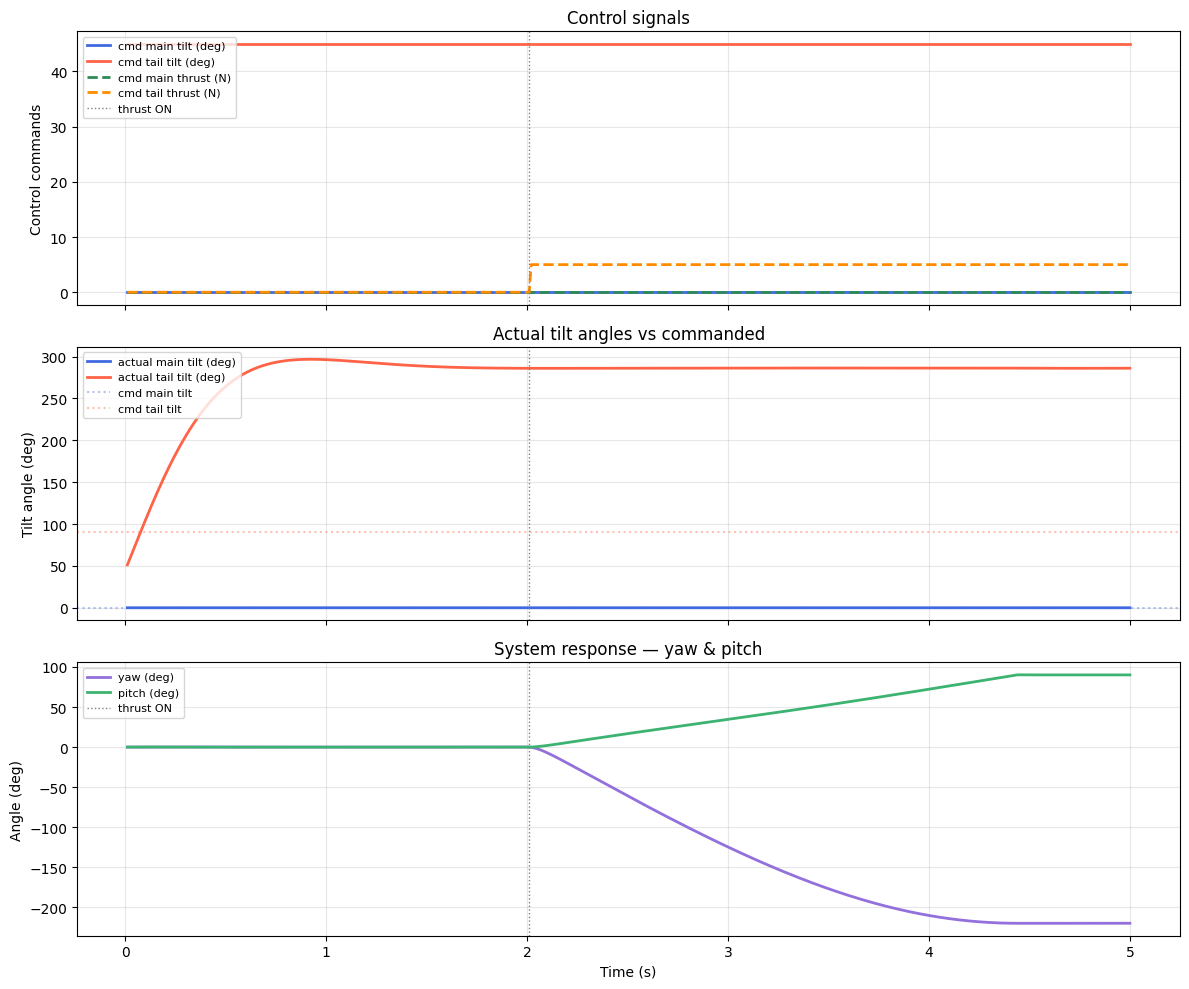

In [ ]:
# @title Plot Response
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
t = log["t"]

# ── Plot 1: Control signals ───────────────────────────────────────────────
ax = axes[0]
ax.plot(t, log["ctrl_main_tilt"],   label="cmd main tilt (deg)",   color="royalblue",  linewidth=2)
ax.plot(t, log["ctrl_tail_tilt"],   label="cmd tail tilt (deg)",   color="tomato",     linewidth=2)
ax.plot(t, log["ctrl_main_thrust"], label="cmd main thrust (N)",   color="seagreen",   linewidth=2, linestyle="--")
ax.plot(t, log["ctrl_tail_thrust"], label="cmd tail thrust (N)",   color="darkorange", linewidth=2, linestyle="--")
ax.axvline(t[200], color="gray", linestyle=":", linewidth=1, label="thrust ON")
ax.set_ylabel("Control commands")
ax.legend(loc="upper left", fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_title("Control signals")

# ── Plot 2: Actual tilt angles ────────────────────────────────────────────
ax = axes[1]
ax.plot(t, log["act_main_tilt"], label="actual main tilt (deg)", color="royalblue", linewidth=2)
ax.plot(t, log["act_tail_tilt"], label="actual tail tilt (deg)", color="tomato",    linewidth=2)
ax.axhline(0.0,  color="royalblue", linestyle=":", alpha=0.4, label="cmd main tilt")
ax.axhline(90.0, color="tomato",    linestyle=":", alpha=0.4, label="cmd tail tilt")
ax.axvline(t[200], color="gray", linestyle=":", linewidth=1)
ax.set_ylabel("Tilt angle (deg)")
ax.legend(loc="upper left", fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_title("Actual tilt angles vs commanded")

# ── Plot 3: System response — yaw and pitch ───────────────────────────────
ax = axes[2]
ax.plot(t, log["act_yaw"],   label="yaw (deg)",   color="mediumpurple", linewidth=2)
ax.plot(t, log["act_pitch"], label="pitch (deg)", color="mediumseagreen", linewidth=2)
ax.axvline(t[200], color="gray", linestyle=":", linewidth=1, label="thrust ON")
ax.set_ylabel("Angle (deg)")
ax.set_xlabel("Time (s)")
ax.legend(loc="upper left", fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_title("System response — yaw & pitch")

plt.tight_layout()
plt.savefig("/content/control_plot.png", dpi=150, bbox_inches="tight")
plt.show()